In [1]:
import os, cv2
import numpy as np
 
LOCAL_SHOP    = '/kaggle/input/datasets/saharamrr/dataset/DataSet/shop_lifters'
LOCAL_NONSHOP = '/kaggle/input/datasets/saharamrr/dataset/DataSet/non_shop_lifters'
 
print(f'shop={len(os.listdir(LOCAL_SHOP))}  non-shop={len(os.listdir(LOCAL_NONSHOP))}')

shop=324  non-shop=531


In [2]:
# 2. IMPORTS

import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, MaxPooling2D, BatchNormalization,
    TimeDistributed, Flatten,
    LSTM, Bidirectional, Dense, Dropout, LayerNormalization,
    Multiply, Reshape, Permute, Lambda, Activation, Add,
    MultiHeadAttention, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

2026-03-24 13:28:41.101682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774358921.546444      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774358921.652506      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774358922.617752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774358922.617795      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774358922.617798      55 computation_placer.cc:177] computation placer alr

In [3]:
# 3. CONFIG

IMG_SIZE    = 256          # min 256 — better spatial resolution
N_FRAMES    = 32           # min 32 — richer temporal context
BATCH_SIZE  = 4            # smaller batch — larger frames need more memory
EPOCHS      = 30
SEED        = 42
SAVE_PATH   = '/kaggle/working/shoplifting_best.keras'
N_CHANNELS  = 4            # RGB(3) + motion-diff(1)
 
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
# 4. LOAD LABELS

# Build video_paths + labels directly from folder structure
# Class 0 = non_shop_lifters | Class 1 = shop_lifters

video_paths, label_list = [], []
 
for fname in sorted(os.listdir(LOCAL_NONSHOP)):
    if fname.endswith('.mp4'):
        video_paths.append(os.path.join(LOCAL_NONSHOP, fname))
        label_list.append(0)
 
for fname in sorted(os.listdir(LOCAL_SHOP)):
    if fname.endswith('.mp4'):
        video_paths.append(os.path.join(LOCAL_SHOP, fname))
        label_list.append(1)
 
labels = np.array(label_list)
print(f'Videos found : {len(video_paths)}')
print(f'Class 0 (Normal): {np.sum(labels==0)} | Class 1 (Shoplifting): {np.sum(labels==1)}')

Videos found : 855
Class 0 (Normal): 531 | Class 1 (Shoplifting): 324


In [5]:
# 5. AUGMENTATION HELPER

def augment_video(frames):
    """
    Manual augmentation — same transform applied to all frames.
    Pure numpy/cv2: no ImageDataGenerator quirks.
    Input/output: float32 in [0, 1], shape (N, H, W, 4)
    """
    H, W = frames.shape[1], frames.shape[2]
 
    # ── Decide transforms once for the whole clip ──
    do_flip       = np.random.rand() < 0.5
    angle         = np.random.uniform(-8, 8)
    brightness    = np.random.uniform(0.88, 1.12)
    tx            = np.random.uniform(-0.05, 0.05) * W   # width shift
    ty            = np.random.uniform(-0.05, 0.05) * H   # height shift
    zoom          = np.random.uniform(0.95, 1.05)
 
    # Build affine matrix (rotation + shift + zoom)
    cx, cy = W / 2, H / 2
    M_rot  = cv2.getRotationMatrix2D((cx, cy), angle, zoom)
    M_rot[0, 2] += tx
    M_rot[1, 2] += ty
 
    out = []
    for f in frames:
        rgb = f[:, :, :3].copy()   # transform RGB only
        if do_flip:
            rgb = rgb[:, ::-1, :]
        rgb = cv2.warpAffine(rgb, M_rot, (W, H),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REFLECT_101)
        rgb = np.clip(rgb * brightness, 0.0, 1.0)
        out.append(rgb)
 
    rgb_stack = np.array(out, dtype=np.float32)       # (N, H, W, 3)
    # Recompute motion after spatial transform
    gray = rgb_stack.mean(axis=-1, keepdims=True)
    diff = np.zeros_like(gray)
    diff[1:] = np.abs(gray[1:] - gray[:-1])
    diff = np.clip(diff * 3.0, 0.0, 1.0)
    return np.concatenate([rgb_stack, diff], axis=-1)  # (N, H, W, 4)

In [6]:
# 6. DATA GENERATOR  (defined ONCE — fixed bug)

class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=BATCH_SIZE,
                 augment=False, shuffle=True, oversample=False, **kw):
        super().__init__(**kw)
        self.batch_size = batch_size
        self.augment    = augment
        self.shuffle    = shuffle
 
        paths  = list(paths)
        labels = list(labels)
 
        if oversample:
            # Duplicate minority class samples until balanced
            cls0 = [(p, l) for p, l in zip(paths, labels) if l == 0]
            cls1 = [(p, l) for p, l in zip(paths, labels) if l == 1]
            majority_n = max(len(cls0), len(cls1))
            while len(cls0) < majority_n:
                cls0 += cls0[:majority_n - len(cls0)]
            while len(cls1) < majority_n:
                cls1 += cls1[:majority_n - len(cls1)]
            combined   = cls0 + cls1
            paths, labels = zip(*combined)
            paths, labels = list(paths), list(labels)
            print(f'  After oversample — Class 0: {sum(1 for l in labels if l==0)} | Class 1: {sum(1 for l in labels if l==1)}')
 
        self.paths   = paths
        self.labels  = list(labels)
        self.indexes = np.arange(len(self.paths))
        self.on_epoch_end()
 
    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))
 
    def _load_frames(self, path):
        """
        Load N_FRAMES uniformly sampled from video.
        Uses decord (primary) -> cv2 (fallback).
        decord is far more reliable in Colab for full video decoding.
        """
        blank = np.zeros((IMG_SIZE, IMG_SIZE, 4), dtype=np.float32)
 
        # Primary: decord
        try:
            from decord import VideoReader, cpu
            vr     = VideoReader(path, ctx=cpu(0))
            total  = len(vr)
            if total == 0:
                raise ValueError('empty video')
            indices = np.linspace(0, total - 1, N_FRAMES, dtype=int)
            frames  = vr.get_batch(indices).asnumpy()  # (N, H, W, 3) uint8 RGB
            if frames.shape[1] != IMG_SIZE or frames.shape[2] != IMG_SIZE:
                frames = np.array([
                    cv2.resize(f, (IMG_SIZE, IMG_SIZE)) for f in frames
                ], dtype=np.uint8)
            rgb = frames.astype(np.float32) / 255.0
            return self._add_motion_channel(rgb)
 
        except Exception:
            pass  # fall through to cv2
 
        # Fallback: cv2
        try:
            cap     = cv2.VideoCapture(path)
            all_raw = []
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_raw.append(frame)
            cap.release()
 
            if len(all_raw) == 0:
                return np.array([blank] * N_FRAMES, dtype=np.float32)
 
            indices = np.linspace(0, len(all_raw) - 1, N_FRAMES, dtype=int)
            rgb = np.array([all_raw[i] for i in indices], dtype=np.float32) / 255.0
            return self._add_motion_channel(rgb)
 
        except Exception:
            return np.zeros((N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), dtype=np.float32)
 
 
    def _add_motion_channel(self, rgb):
        """
        rgb: (N, H, W, 3) float32 [0,1]
        returns: (N, H, W, 4) — RGB + amplified frame-difference (motion)
        """
        gray = rgb.mean(axis=-1, keepdims=True)       # (N, H, W, 1)
        diff = np.zeros_like(gray)
        diff[1:] = np.abs(gray[1:] - gray[:-1])
        diff = np.clip(diff * 3.0, 0.0, 1.0)
        return np.concatenate([rgb, diff], axis=-1)   # (N, H, W, 4)
 
    def __getitem__(self, idx):
        bi = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for i in bi:
            frames = self._load_frames(self.paths[i])
            if self.augment:
                frames = augment_video(frames)
            X.append(frames)
            y.append(self.labels[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [7]:
# 7. CLEAN BAD VIDEOS + SPLIT

bad_videos = []
for p in video_paths:
    cap = cv2.VideoCapture(p)
    ret, frame = cap.read()
    cap.release()
    if not ret or frame is None or frame.mean() <= 1.0:
        bad_videos.append(p)
 
if bad_videos:
    print(f' {len(bad_videos)} unreadable videos found — removing from dataset')
    bad_set = set(bad_videos)
    clean   = [(p, l) for p, l in zip(video_paths, labels.tolist()) if p not in bad_set]
    video_paths, labels = zip(*clean)
    video_paths = list(video_paths)
    labels      = np.array(labels)
    print(f'Remaining: {len(video_paths)} videos')
else:
    print(f'All {len(video_paths)} videos readable ')
 
# Re-split after cleaning
tv, test_v, tl, test_l = train_test_split(
    video_paths, labels, test_size=0.15, stratify=labels, random_state=SEED)
tv, val_v, tl, val_l = train_test_split(
    tv, tl, test_size=0.20, stratify=tl, random_state=SEED)
 
train_gen = VideoDataGenerator(tv,     tl,     augment=True,  shuffle=True,  oversample=True)
val_gen   = VideoDataGenerator(val_v,  val_l,  augment=False, shuffle=False, oversample=False)
test_gen  = VideoDataGenerator(test_v, test_l, augment=False, shuffle=False, oversample=False)
print(f'Train={len(tv)} | Val={len(val_v)} | Test={len(test_v)}')
print(f'Class 0 (train): {np.sum(np.array(tl)==0)} | Class 1 (train): {np.sum(np.array(tl)==1)}')
 
# Compute class weights — handles imbalance automatically
class_weights = dict(enumerate(compute_class_weight(
    'balanced', classes=np.unique(tl), y=tl)))
print(f'Class weights: {class_weights}')
 
# Quick sanity check
X_s, y_s = train_gen[0]
print(f'\nBatch shape : {X_s.shape}')
print(f'Mean pixel  : {X_s.mean():.4f}')
assert X_s.shape == (BATCH_SIZE, N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), \
    f'Wrong shape: {X_s.shape}'
assert X_s.mean() > 0.01, \
    f'Still black frames! mean={X_s.mean():.5f} — codec issue, try: pip install opencv-python-headless'

All 855 videos readable 
  After oversample — Class 0: 360 | Class 1: 360
Train=580 | Val=146 | Test=129
Class 0 (train): 360 | Class 1 (train): 220
Class weights: {0: np.float64(0.8055555555555556), 1: np.float64(1.3181818181818181)}

Batch shape : (4, 32, 256, 256, 4)
Mean pixel  : 0.3566


In [8]:
# 8. MODEL — Optimized CNN-BiLSTM 


from tensorflow.keras.layers import GlobalAveragePooling2D

def build_frame_cnn():
    """
    CNN Block: Extracts core spatial features from each frame.
    Switching from Flatten to GlobalAveragePooling2D (GAP) 
    to reduce parameters and focus on 'what' is in the frame.
    """
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS)) # (256, 256, 4)

    # Block 1: Capture low-level edges/colors
    x = Conv2D(16, 3, padding='same', use_bias=False)(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # → 128×128×16

    # Block 2
    x = Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # → 64×64×32

    # Block 3: Mid-level features
    x = Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # → 32×32×64

    # Block 4
    x = Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)                  # → 16×16×64

    # Block 5: High-level semantics
    x = Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # CRITICAL CHANGE: Use GAP instead of Flatten
    # This prevents the 4096-dim explosion and helps the LSTM learn faster.
    x = GlobalAveragePooling2D()(x)         # → 128-dim vector per frame

    # Small bottleneck to clean up the features
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)

    return Model(inp, x, name='frame_cnn')


def build_model():
    vid_input = Input(shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, N_CHANNELS), name='video')

    # 1. Feature Extraction (TimeDistributed)
    frame_cnn = build_frame_cnn()
    x = TimeDistributed(frame_cnn, name='td_cnn')(vid_input)   # (B, 32, 128)
    x = LayerNormalization()(x)

    # 2. Temporal Modeling (Bidirectional LSTM)
    # Reduced units to match the 400-600 video dataset size
    x = Bidirectional(
        LSTM(64, return_sequences=False, dropout=0.3)
    )(x)                                                       # (B, 128)

    # 3. Simplified Classifier
    # Removed heavy L2 and extra layers to stop the 0.37 accuracy stagnation
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    
    # Final Sigmoid Layer
    out = Dense(1, activation='sigmoid', name='output')(x)

    return Model(vid_input, out, name='ShopliftingDetector')

In [9]:
# 9. COMPILE & TRAIN

tf.keras.backend.clear_session()
model = build_model()
 
# CosineDecay — decay_steps must be in BATCHES not epochs
# total_batches = steps_per_epoch × EPOCHS
total_steps = len(train_gen) * EPOCHS   
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4, 
    decay_steps=total_steps,
    alpha=0.1
)

# ضيف epsilon للـ Adam عشان الثبات
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0, epsilon=1e-7)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
 
model.summary()

 
# Callbacks
callbacks = [
    ModelCheckpoint(
        SAVE_PATH, monitor='val_auc',
        save_best_only=True, mode='max', verbose=1
    ),
    EarlyStopping(
        monitor='val_auc', patience=15,
        restore_best_weights=True, mode='max', verbose=1
    ),
]
 
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

I0000 00:00:1774358987.492428      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774358987.498247      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ShopliftingDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video (InputLayer)              │ (None, 32, 256, 256,   │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_cnn (TimeDistributed)        │ (None, 32, 128)        │       151,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,329 (1013.00 KB)

 Trainable params: 258,721 (1010.63 KB)

 Non-trainable params: 608 (2.38 KB)

Epoch 1/30


I0000 00:00:1774359031.276942    6137 cuda_dnn.cc:529] Loaded cuDNN version 91002


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5337 - auc: 0.5318 - loss: 0.7310 - precision: 0.5094 - recall: 0.6540
Epoch 1: val_auc improved from -inf to 0.74685, saving model to /kaggle/working/shoplifting_best.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 510s 3s/step - accuracy: 0.5337 - auc: 0.5319 - loss: 0.7310 - precision: 0.5095 - recall: 0.6547 - val_accuracy: 0.3767 - val_auc: 0.7469 - val_loss: 0.7631 - val_precision: 0.3767 - val_recall: 1.0000
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5115 - auc: 0.5157 - loss: 0.7302 - precision: 0.5102 - recall: 0.8392
Epoch 2: val_auc improved from 0.74685 to 0.76144, saving model to /kaggle/working/shoplifting_best.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 457s 3s/step - accuracy: 0.5116 - auc: 0.5159 - loss: 0.7302 - precision: 0.5102 - recall: 0.8392 - val_accuracy: 0.4726 - val_auc: 0.7614 - val_loss: 0.6882 - val_precision: 0.4154 - val_recall: 0.9818
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5


 Validation Set 
              precision    recall  f1-score   support

      Normal       1.00      0.18      0.30        91
 Shoplifting       0.42      1.00      0.59        55

    accuracy                           0.49       146
   macro avg       0.71      0.59      0.45       146
weighted avg       0.78      0.49      0.41       146

ROC-AUC: 1.0000
Best threshold: 0.80 → F1=0.6918
Report with optimal threshold:
              precision    recall  f1-score   support

      Normal       1.00      0.46      0.63        91
 Shoplifting       0.53      1.00      0.69        55

    accuracy                           0.66       146
   macro avg       0.76      0.73      0.66       146
weighted avg       0.82      0.66      0.65       146



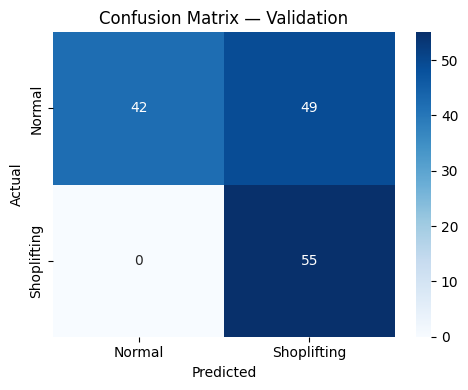


 Test Set 
              precision    recall  f1-score   support

      Normal       1.00      0.26      0.42        80
 Shoplifting       0.45      1.00      0.62        49

    accuracy                           0.54       129
   macro avg       0.73      0.63      0.52       129
weighted avg       0.79      0.54      0.49       129

ROC-AUC: 1.0000


In [10]:
# 11. EVALUATION

print('\n Validation Set ')
y_true_val  = val_l
y_prob_val  = model.predict(val_gen, verbose=0).ravel()
y_pred_val  = (y_prob_val > 0.5).astype(int)
 
print(classification_report(y_true_val, y_pred_val,
                             target_names=['Normal', 'Shoplifting']))
print(f'ROC-AUC: {roc_auc_score(y_true_val, y_prob_val):.4f}')
 
# Threshold Tuning (maximize F1 on val set) 
from sklearn.metrics import f1_score
best_thr, best_f1 = 0.5, 0.0
for thr in np.arange(0.2, 0.8, 0.01):
    preds = (y_prob_val > thr).astype(int)
    f1    = f1_score(y_true_val, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr
print(f'Best threshold: {best_thr:.2f} → F1={best_f1:.4f}')
y_pred_val = (y_prob_val > best_thr).astype(int)
print('Report with optimal threshold:')
print(classification_report(y_true_val, y_pred_val, target_names=['Normal', 'Shoplifting']))
 
cm = confusion_matrix(y_true_val, y_pred_val)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Validation')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
 
print('\n Test Set ')
y_true_test = test_l
y_prob_test = model.predict(test_gen, verbose=0).ravel()
y_pred_test = (y_prob_test > 0.5).astype(int)
print(classification_report(y_true_test, y_pred_test,
                             target_names=['Normal', 'Shoplifting']))
print(f'ROC-AUC: {roc_auc_score(y_true_test, y_prob_test):.4f}')

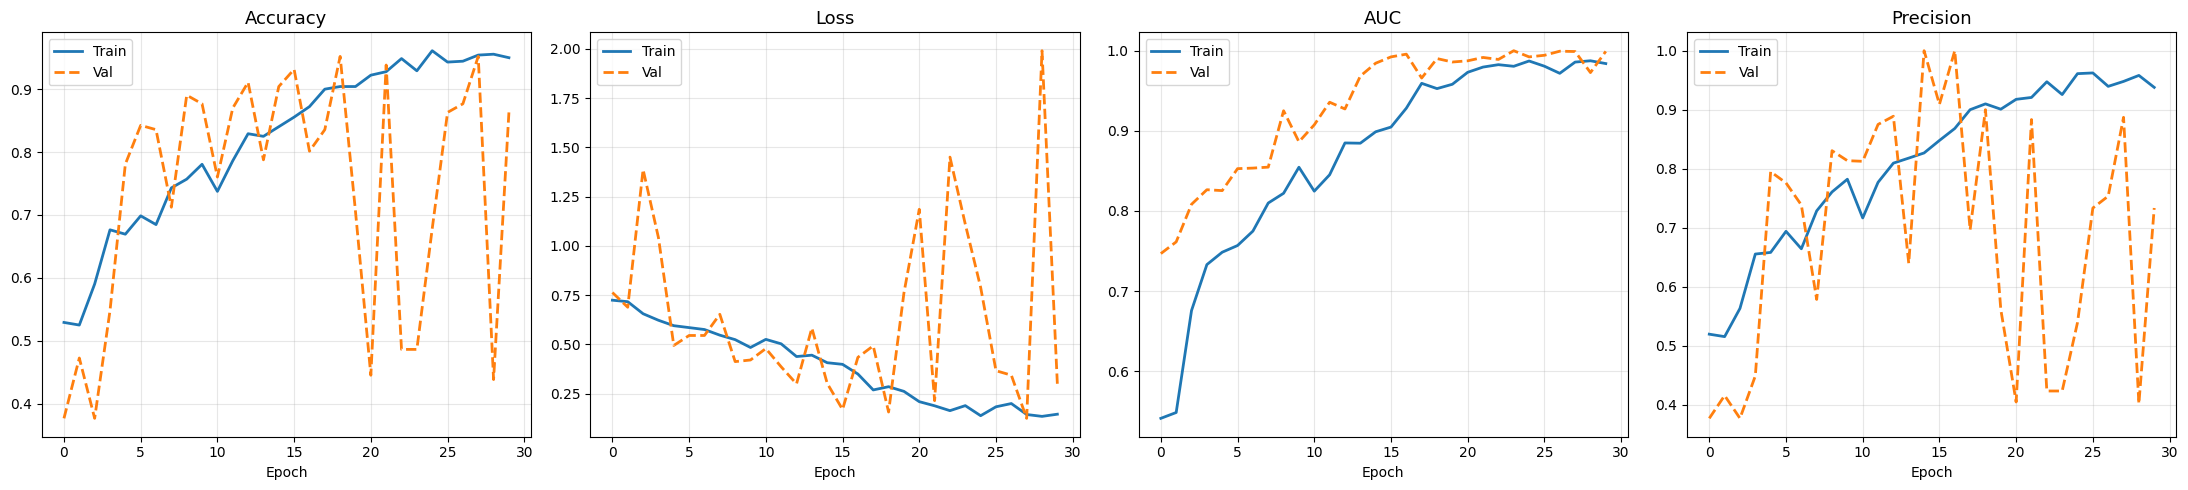


 Done! Model saved to: /kaggle/working/shoplifting_best.keras


In [11]:
# 12. TRAINING CURVES

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['accuracy', 'loss', 'auc', 'precision']
titles  = ['Accuracy', 'Loss', 'AUC', 'Precision']
 
for ax, key, title in zip(axes, metrics, titles):
    ax.plot(history.history[key],          label='Train', linewidth=2)
    ax.plot(history.history[f'val_{key}'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
 
print('\n Done! Model saved to:', SAVE_PATH)